<a href="https://colab.research.google.com/github/lorenzogenera/Orbit_Sims/blob/main/An_exploration_about_orbits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Questions:**

1. Three-body figure-eight
The famous stable three-body solution has all three masses chasing each
other in a figure-eight. Try to reproduce it by finding the right
initial
conditions and see how sensitive it is to perturbations.
2. Hohmann transfer orbit
Simulate a spacecraft transferring from a low circular orbit to a
higher
one using two impulsive burns. How does the delta-v cost scale with the
ratio of the orbit radii?
3. Precessing orbits (GR correction)
Add a small 1/r^3 correction to Newtonian gravity (a crude GR
approximation) and watch the ellipse precess. Compare the precession
rate
to Mercury's observed 43 arcseconds per century.
4. Lagrange points
In a rotating two-body (Earth-Sun) frame, find the five Lagrange points
numerically by mapping out the effective potential. Which ones are
stable?

**Part 1.1:**

3 Bodies- one mass centered @ origin

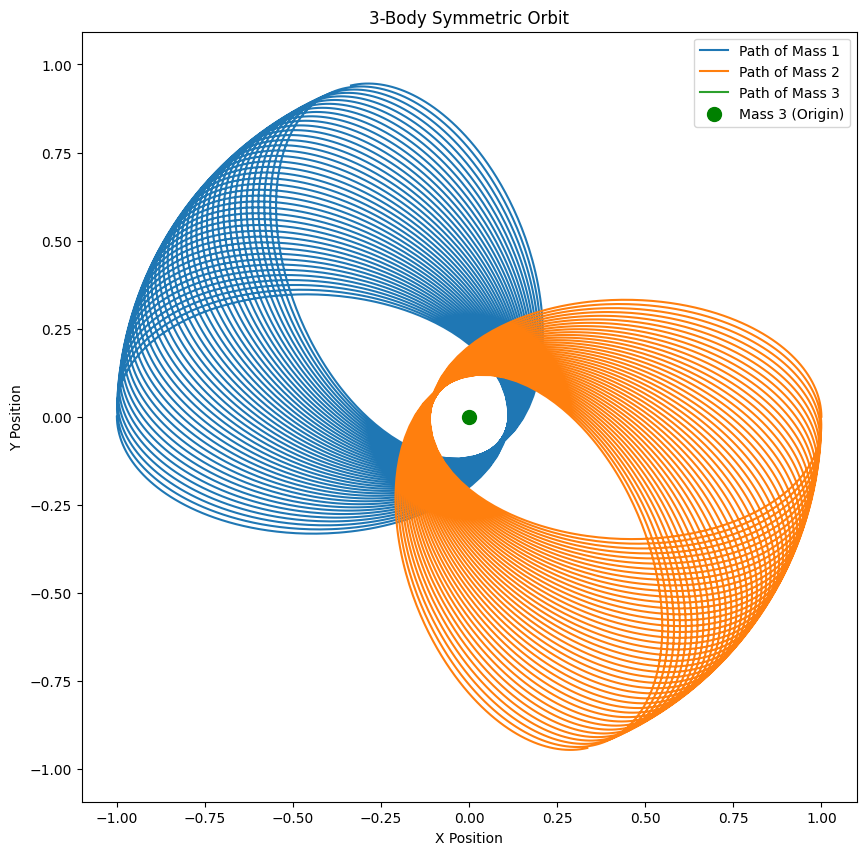

The Initial Conditions for Bodies With Equal Mass:
----------------------------------------
Body 1:
  Position: [-0.34023536674098775, 0.9391564617851414]
  Velocity: [-0.48897867627127906, -0.11983620896095536]
----------------------------------------
Body 2:
  Position: [0.34023536674098775, -0.9391564617851414]
  Velocity: [0.48897867627127906, 0.11983620896095536]
----------------------------------------
Body 3:
  Position: [0.0, 0.0]
  Velocity: [0.0, 0.0]
----------------------------------------



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gravitational constant
G = 1.0
#Time step
dt = 0.01
#simulate for an appropriate time to see, otherwise they overlap too much
num_steps = 10000

#Initial conditions (equal/opposite)
#Positions, velocities, mass
bodies = [
    {"pos": [-1, 0], "vel": [0, -0.5], "mass": 1.0, "path_x": [], "path_y": []},
    {"pos": [1, 0], "vel": [0, 0.5], "mass": 1.0, "path_x": [], "path_y": []},
    {"pos": [0, 0], "vel": [0, 0], "mass": 1.0, "path_x": [], "path_y": []}
]

#Grav Force between 2 bodies
def calculate_force(b1, b2):
    dx = b2["pos"][0] - b1["pos"][0]
    dy = b2["pos"][1] - b1["pos"][1]

    r = (dx**2 + dy**2)**0.5
    if r == 0:
        return [0, 0]
#Magnitude of the force
    F_mag = G * b1["mass"] * b2["mass"] / r**2
#Fx,y=
    Fx = F_mag * dx / r
    Fy = F_mag * dy / r
    return [Fx, Fy]

#Simulation Loop
for step in range(num_steps):
    #Store current positions for plotting
    for body in bodies:
        body["path_x"].append(body["pos"][0])
        body["path_y"].append(body["pos"][1])

    #Calculate forces on each body
    forces = []
    for i in range(len(bodies)):
        net_force = [0, 0]
        for j in range(len(bodies)):
            if i != j:
                #Force on body i due to body j
                F_ij = calculate_force(bodies[i], bodies[j])
                net_force[0] += F_ij[0]
                net_force[1] += F_ij[1]
        forces.append(net_force)

    #Update velocities and positions (Euler-Cromer is easier for me)
    for i in range(len(bodies)):
        # Update velocity
        bodies[i]["vel"][0] += forces[i][0] / bodies[i]["mass"] * dt
        bodies[i]["vel"][1] += forces[i][1] / bodies[i]["mass"] * dt
        # Update position
        bodies[i]["pos"][0] += bodies[i]["vel"][0] * dt
        bodies[i]["pos"][1] += bodies[i]["vel"][1] * dt

#good plot
plt.figure(figsize=(10, 10))

#plot path
for i, body in enumerate(bodies):
    plt.plot(body["path_x"], body["path_y"], label=f'Path of Mass {i+1}')

#plot start m3
plt.scatter(0, 0, color='green', s=100, label='Mass 3 (Origin)', zorder=5)

plt.title("3-Body Symmetric Orbit")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.axis('equal') # Keep the aspect ratio square for visual clarity
plt.show()

print("The Initial Conditions for Bodies With Equal Mass:")

print("-" * 40)
for i, body in enumerate(bodies):
    print(f"Body {i+1}:")
    print(f"  Position: {body['pos']}")
    print(f"  Velocity: {body['vel']}")
    print("-" * 40)
print()

You can see mass 1 and 2 do not start and end in the same position, but the orbits are stable.

This is a symmetric periodic-looking trajectory, not the figure-eight. The configuration is preserved by symmetry, not dynamical stability.

They will loop around, with enough time.

The orbit will precess.

**Question 1, attempt 2:**

**OR:**

Thanks to Chenciner and Montgomery, in 2000, we know the exact initial values required for a stable figure 8 orbit.

Changing any of the inital values, or even rounding them shoots a mass off the graph.

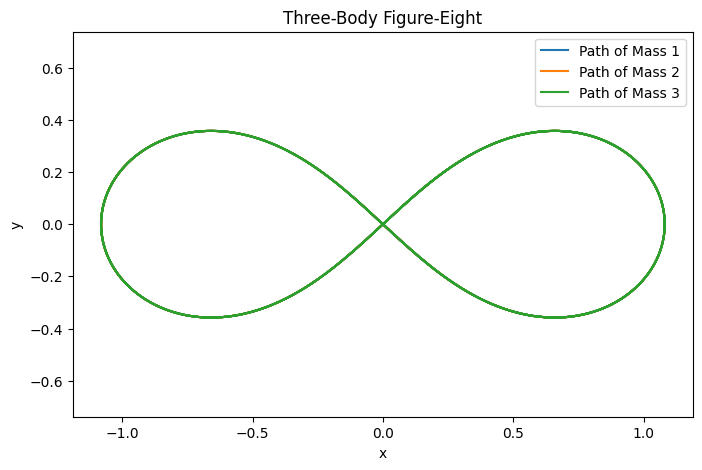

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Figure-eight initial conditions (Chenciner & Montgomery 2000, numerical values from Moore 1993)

G = 1.0
m = 1.0

#Initial positions
r1 = np.array([ 0.97000436, -0.24308753])
r2 = np.array([-0.97000436,  0.24308753])
r3 = np.array([ 0.0,         0.0       ])

#Initial velocities
v3 = np.array([ 0.93240737,  0.86473146])
v1 = -v3 / 2
v2 = -v3 / 2

dt = 0.001
t_end = 20  # roughly 3 periods
t_range = np.arange(0, t_end, dt)

# Store all traj
traj = {i: {'x': [], 'y': []} for i in range(3)}

positions = [r1.copy(), r2.copy(), r3.copy()]
velocities = [v1.copy(), v2.copy(), v3.copy()]

def acceleration(positions, i):
    a = np.zeros(2)
    for j in range(3):
        if j != i:
            r_vec = positions[j] - positions[i]
            r = np.linalg.norm(r_vec)
            a += G * m * r_vec / r**3
    return a

#RK2 loop
for t in t_range:
    for i in range(3):
        traj[i]['x'].append(positions[i][0])
        traj[i]['y'].append(positions[i][1])

    #compute accelerations at current step
    accels = [acceleration(positions, i) for i in range(3)]

    #midpoint pos and vel
    pos_mid = [positions[i] + 0.5*dt*velocities[i] for i in range(3)]
    vel_mid = [velocities[i] + 0.5*dt*accels[i] for i in range(3)]

    #accels at midpoint
    accels_mid = [acceleration(pos_mid, i) for i in range(3)]

    #full step
    for i in range(3):
        positions[i] = positions[i] + dt * vel_mid[i]
        velocities[i] = velocities[i] + dt * accels_mid[i]

#Plot
plt.figure(figsize=(8, 5))
#all 3 in same line
for i in range(3):
    plt.plot(traj[i]['x'], traj[i]['y'], label=f'Path of Mass {i+1}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Three-Body Figure-Eight')
plt.axis('equal')
plt.legend()
plt.show()

All three masses follow the exact same curve.

They are just shifted in equal phases, so they are displayed, but not visible.

The 3 masses are chasing eachother.

**Part 2:**

2. Hohmann transfer orbit Simulate a spacecraft transferring from a low circular orbit to a higher one using two impulsive burns. How does the delta-v cost scale with the ratio of the orbit radii

In [3]:
import numpy as np

# Constants
GC = 6.6743e-11 # gravitational constant, m^3 kg^-1 s^-2
mEarth = 5.972e24 # mass of Earth, kg
mu = GC * mEarth # standard gravitational parameter, m^3/s^2
R_earth = 6.371e6 # Earth's radius, m

# Orbit radii (measured from Earth's center)
r1 = R_earth + 300e3 # Low Earth Orbit (300 km altitude)
r2 = R_earth + 35786e3 # Geostationary Orbit (35,786 km altitude)


def HoffT(r1, r2, mu):
    """Compute Hohmann transfer parameters between two circular orbits."""
    # Circular orbital velocities
    v1_circ = np.sqrt(mu / r1)
    v2_circ = np.sqrt(mu / r2)

    # Semi-major axis of the transfer ellipse
    A_T = (r1 + r2) / 2

    # Velocities at periapsis and apoapsis of the transfer ellipse (vis-viva)
    v1_transfer = np.sqrt(mu * (2/r1 - 1/A_T))
    v2_transfer = np.sqrt(mu * (2/r2 - 1/A_T))

    # Required burns
    delta_v1 = v1_transfer - v1_circ # boost from LEO into transfer
    delta_v2 = v2_circ - v2_transfer # circularize at GEO

    # Time of flight = half the transfer-ellipse period
    period_transfer = 2 * np.pi * np.sqrt(A_T**3 / mu)
    flight_time = period_transfer / 2

    return {
        "v1_circ (m/s)": v1_circ,
        "v2_circ (m/s)": v2_circ,
        "delta_v1 (m/s)": delta_v1,
        "delta_v2 (m/s)": delta_v2,
        "total_delta_v (m/s)": abs(delta_v1) + abs(delta_v2),
        "time_of_flight (s)": flight_time,
        "time_of_flight (days)": flight_time / (24 * 3600),
    }


# Run the transfer for LEO to GEO
result = HoffT(r1, r2, mu)

print("=" * 55)
print("   Hohmann Transfer Results (LEO to GEO):")
print("=" * 55)
print(f"  Initial orbit radius (r1):     {r1/1000:>12,.2f} km")
print(f"  Final orbit radius   (r2):     {r2/1000:>12,.2f} km")
print(f"  Orbit ratio (r2 / r1):         {r2/r1:>12.3f}")
print("-" * 55)
print(f"  Initial circular velocity:     {result['v1_circ (m/s)']:>12,.2f} m/s")
print(f"  Final circular velocity:       {result['v2_circ (m/s)']:>12,.2f} m/s")
print("-" * 55)
print(f"  Burn 1  Δv (LEO → transfer):   {result['delta_v1 (m/s)']:>12,.2f} m/s")
print(f"  Burn 2  Δv (transfer → GEO):   {result['delta_v2 (m/s)']:>12,.2f} m/s")
print(f"  Total   Δv:                    {result['total_delta_v (m/s)']:>12,.2f} m/s")
print("-" * 55)
print(f"  Time of flight:                {result['time_of_flight (s)']:>12,.2f} seconds")
print(f"                                 {result['time_of_flight (days)']:>12.4f} days")
print("=" * 55)


   Hohmann Transfer Results (LEO to GEO):
  Initial orbit radius (r1):         6,671.00 km
  Final orbit radius   (r2):        42,157.00 km
  Orbit ratio (r2 / r1):                6.319
-------------------------------------------------------
  Initial circular velocity:         7,729.78 m/s
  Final circular velocity:           3,074.88 m/s
-------------------------------------------------------
  Burn 1  Δv (LEO → transfer):       2,427.62 m/s
  Burn 2  Δv (transfer → GEO):       1,467.55 m/s
  Total   Δv:                        3,895.17 m/s
-------------------------------------------------------
  Time of flight:                   18,982.16 seconds
                                       0.2197 days


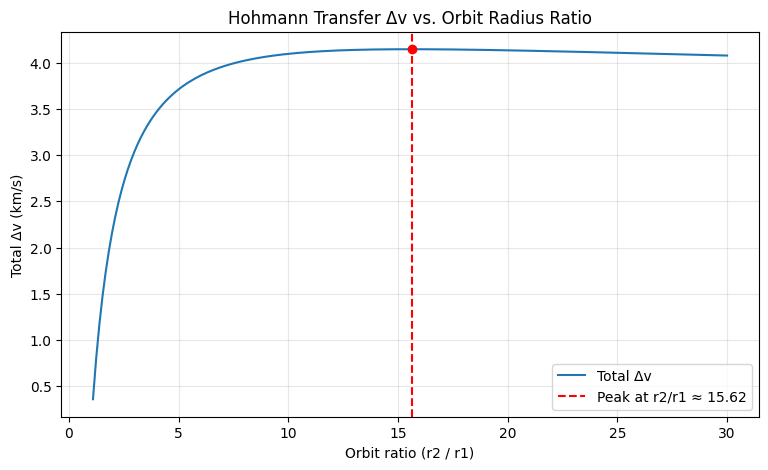

The peak Δv of 4.145 km/s occurs at r2/r1 ≈ 15.62


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants (make sure these are already defined; redefining here just to be safe)
GC = 6.6743e-11
mEarth = 5.972e24
mu = GC * mEarth

# Fix r1 (LEO at 300 km altitude) and sweep r2
R_earth = 6.371e6
r1 = R_earth + 300e3

# Range of ratios to test
ratios = np.linspace(1.1, 30, 200)

# Collect total delta-v for each ratio
total_dv = []
for ratio in ratios:
    r2 = ratio * r1
    result = HoffT(r1, r2, mu)
    total_dv.append(result["total_delta_v (m/s)"]) # to match HoffT function output

total_dv = np.array(total_dv) / 1000  # convert to km/s

# Find the peak
peak_idx = np.argmax(total_dv)
peak_ratio = ratios[peak_idx]
peak_dv = total_dv[peak_idx]

# Plot
plt.figure(figsize=(9, 5))
plt.plot(ratios, total_dv, label="Total Δv")
plt.axvline(peak_ratio, color="red", linestyle="--",
            label=f"Peak at r2/r1 ≈ {peak_ratio:.2f}")
plt.scatter([peak_ratio], [peak_dv], color="red", zorder=5)

plt.xlabel("Orbit ratio (r2 / r1)")
plt.ylabel("Total Δv (km/s)")
plt.title("Hohmann Transfer Δv vs. Orbit Radius Ratio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"The peak Δv of {peak_dv:.3f} km/s occurs at r2/r1 ≈ {peak_ratio:.2f}")

The total Δv is not monotonic in the orbit ratio.

Physically, this is why the bi-elliptic transfer (three burns instead of two) becomes more efficient than a Hohmann transfer. For orbit ratios greater than ~11.94, bieliptic begins to beat out Hohmann. At 15.62, it will always beat Hohmann.

**Part. 3:**

Now, Im going to add a small 1/r³ correction to Newtonian gravity, watch the ellipse precess and compare to Mercury's 43 seconds per century.

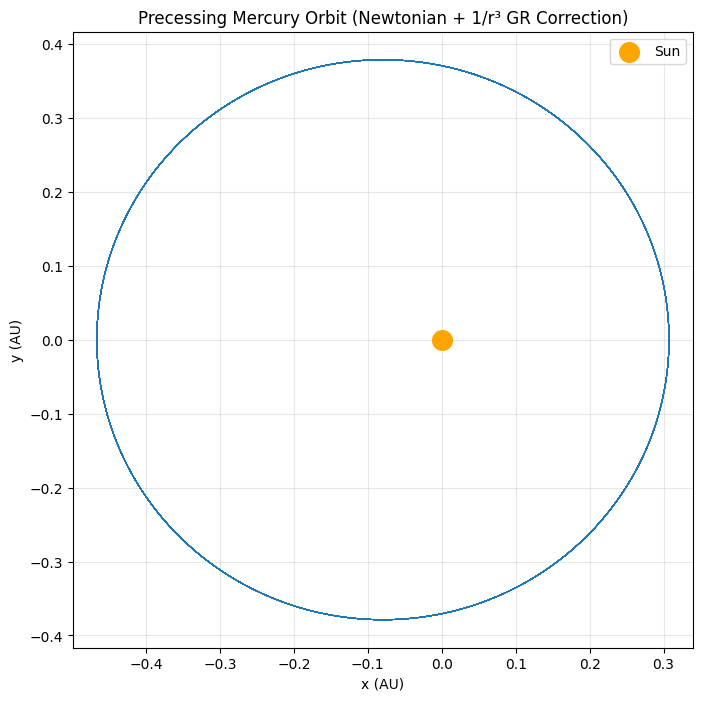

Orbits simulated:        20.0
Eccentricity check:      start = 0.2056, end = 0.2056 (should match)
 
Per-orbit precession:    0.1026 arcseconds
Simulation:              42.64 arcseconds/century
Schwarzschild analytic:  43.02 arcseconds/century
Observed (GR):           43.0 arcseconds/century
Sim error vs observed:   0.8%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

#Constants
G = 6.6743e-11 #m^3 kg^-1 s^-2
M = 1.989e30 #mass of the Sun, kg
c = 2.998e8 #speed of light, m/s
AU = 1.496e11 #astronomical unit, m

#Mercury's
a = 0.387 * AU # semi-major axis,
e = 0.2056 # eccentricity

#Perihelion equations
r_p = a * (1 - e) #distance
v_p = np.sqrt(G * M * (1 + e) / (a * (1 - e))) #speed

#GR correction strength
L_specific = r_p * v_p #angular momentum per unit mass at perihelion
alpha = (3 * G * M * L_specific**2 / c**2)

#initial conditions: start, moving in +y direction
pos = np.array([r_p, 0.0])
vel = np.array([0.0, v_p])

def acceleration(pos, alpha):
    r = np.linalg.norm(pos)
    r_hat = pos / r
    a_newton = -G * M / r**2
    a_gr = -alpha / r**4
    return (a_newton + a_gr) * r_hat

#Velocity Verlet
dt = 60 * 1 #1 minutes
n_orbits_target = 20 #enough, but not too hard on computer
T_orbit = 2 * np.pi * np.sqrt(a**3 / (G * M)) #Mercury's period (~88 days)
n_steps = int(n_orbits_target * T_orbit / dt)

xs, ys = [], []

""" - leftover
#perihelion_angles = []

#prev_r = np.linalg.norm(pos)
#prev_prev_r = prev_r + 1
"""

acc = acceleration(pos, alpha)

#initial perihelion direction via the Laplace-Runge-Lenz vector
#this vector always points from the Sun to perihelion, so we just measure how it rotates
Lz0 = pos[0]*vel[1] - pos[1]*vel[0]
r0  = np.linalg.norm(pos)
ex0 =  vel[1]*Lz0/(G*M) - pos[0]/r0
ey0 = -vel[0]*Lz0/(G*M) - pos[1]/r0
angle0 = np.arctan2(ey0, ex0)

for step in range(n_steps):
    xs.append(pos[0])
    ys.append(pos[1])

    #Velocity Verlet step:
    pos     = pos + vel * dt + 0.5 * acc * dt**2
    new_acc = acceleration(pos, alpha)
    vel     = vel + 0.5 * (acc + new_acc) * dt
    acc     = new_acc

#final perihelion direction
Lz = pos[0]*vel[1] - pos[1]*vel[0]
r  = np.linalg.norm(pos)
ex =  vel[1]*Lz/(G*M) - pos[0]/r
ey = -vel[0]*Lz/(G*M) - pos[1]/r
angle_f = np.arctan2(ey, ex)
e_final = np.sqrt(ex**2 + ey**2)# ~0.2056

#total drift, unwrapped
drift_rad = angle_f - angle0
while drift_rad >  np.pi: drift_rad -= 2*np.pi
while drift_rad < -np.pi: drift_rad += 2*np.pi

orbits_done            = n_steps * dt / T_orbit
drift_per_orbit_arcsec = np.degrees(drift_rad) * 3600 / orbits_done
orbits_per_century     = (100 * 365.25 * 86400) / T_orbit
sim_arcsec_per_century = drift_per_orbit_arcsec * orbits_per_century

#analytical Schwarzschild result for comparison
analytic_rad    = 6 * np.pi * G * M / (a * c**2 * (1 - e**2))
analytic_arcsec = np.degrees(analytic_rad) * 3600 * orbits_per_century

#plot the orbit
plt.figure(figsize=(8, 8))
plt.plot(np.array(xs)/AU, np.array(ys)/AU, lw=0.7)
plt.scatter([0], [0], color='orange', s=200, label='Sun', zorder=5)
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Precessing Mercury Orbit (Newtonian + 1/r³ GR Correction)')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Orbits simulated:        {orbits_done:.1f}")
print(f"Eccentricity check:      start = {e:.4f}, end = {e_final:.4f}", "(should match)")
print(" ")
print(f"Per-orbit precession:    {drift_per_orbit_arcsec:.4f} arcseconds")
print(f"Simulation:              {sim_arcsec_per_century:.2f} arcseconds/century")
print(f"Schwarzschild analytic:  {analytic_arcsec:.2f} arcseconds/century")
print(f"Observed (GR):           43.0 arcseconds/century")
print(f"Sim error vs observed:   {abs(sim_arcsec_per_century - 43)/43 * 100:.1f}%")

But again, this is not visually appealing, so I attempted to make the GR correction roatation visible.

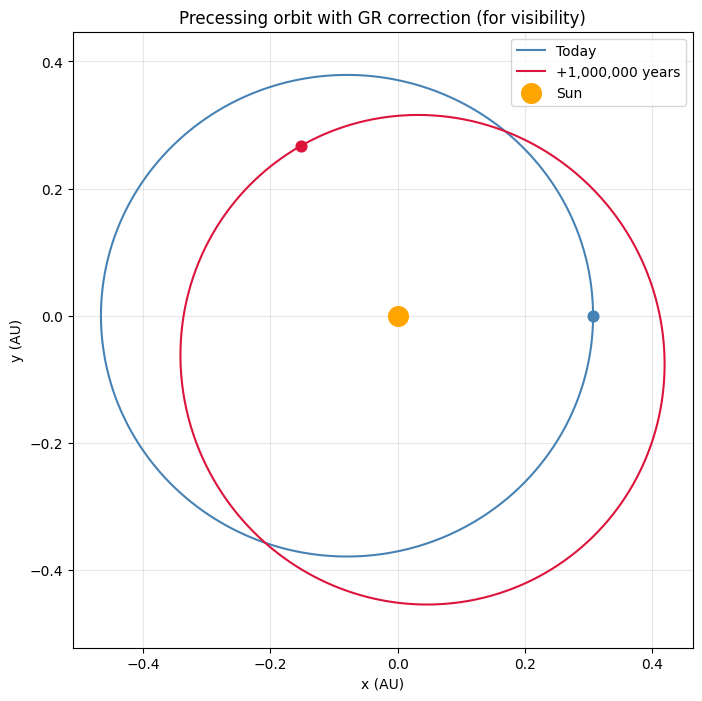

In 1,000,000 years:
  Mercury completes ~4,154,134 orbits.
  Perihelion rotates by 119.51°, due to GR.


In [6]:
#precession rate from analytical Schwarzschild result
years_ahead = 1_000_000

# Per-orbit precession (radians) and total rotation after N years
delta_per_orbit = 6 * np.pi * G * M / (a * c**2 * (1 - e**2))
T_years = T_orbit / (365.25 * 86400)
n_orbits_ahead = years_ahead / T_years
total_rotation = delta_per_orbit * n_orbits_ahead   # radians

# Build a clean ellipse (today) — Mercury's actual shape, perihelion on +x axis
theta = np.linspace(0, 2*np.pi, 500)
r_ellipse = a * (1 - e**2) / (1 + e * np.cos(theta)) # polar form of ellipse
x_today = r_ellipse * np.cos(theta) / AU
y_today = r_ellipse * np.sin(theta) / AU

# Same ellipse, rotated by total_rotation around the Sun
ct, st = np.cos(total_rotation), np.sin(total_rotation)
x_future = ct * x_today - st * y_today
y_future = st * x_today + ct * y_today

plt.figure(figsize=(8, 8))
plt.plot(x_today,  y_today,  color='steelblue', lw=1.5, label='Today')
plt.plot(x_future, y_future, color='crimson',   lw=1.5,
         label=f'+{years_ahead:,} years')
plt.scatter([0], [0], color='orange', s=200, zorder=5, label='Sun')

# Mark each perihelion to make the rotation obvious
plt.scatter([a*(1-e)/AU], [0], color='steelblue', s=60, zorder=6)
plt.scatter([a*(1-e)/AU * ct], [a*(1-e)/AU * st],
            color='crimson', s=60, zorder=6)

plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Precessing orbit with GR correction (for visibility)')
plt.axis('equal')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

#print values
print(f"In {years_ahead:,} years:")
print(f"  Mercury completes ~{n_orbits_ahead:,.0f} orbits.")
print(f"  Perihelion rotates by {np.degrees(total_rotation):.2f}°, due to GR.")

Explanation of problems/plots:

Mercury's perihelion precesses by about 5,600 arcseconds per century, but Newtonian gravity said it should only be 5,557. The 43 arcseconds was the leftover that Newtonian physics couldn't explain.

Mercury's real GR precession is 0.1 arcseconds per orbit. Over 100 orbits, that's a total angular shift of about 10 arcseconds, or around .003 degrees. Thus, you can't see it on the graph.

I wanted to be able to see this change. The second plot shows how the orbit will change. After 3,000,000 years, the orientations of the orbits will be the around the same as today's.

**Part 4:**

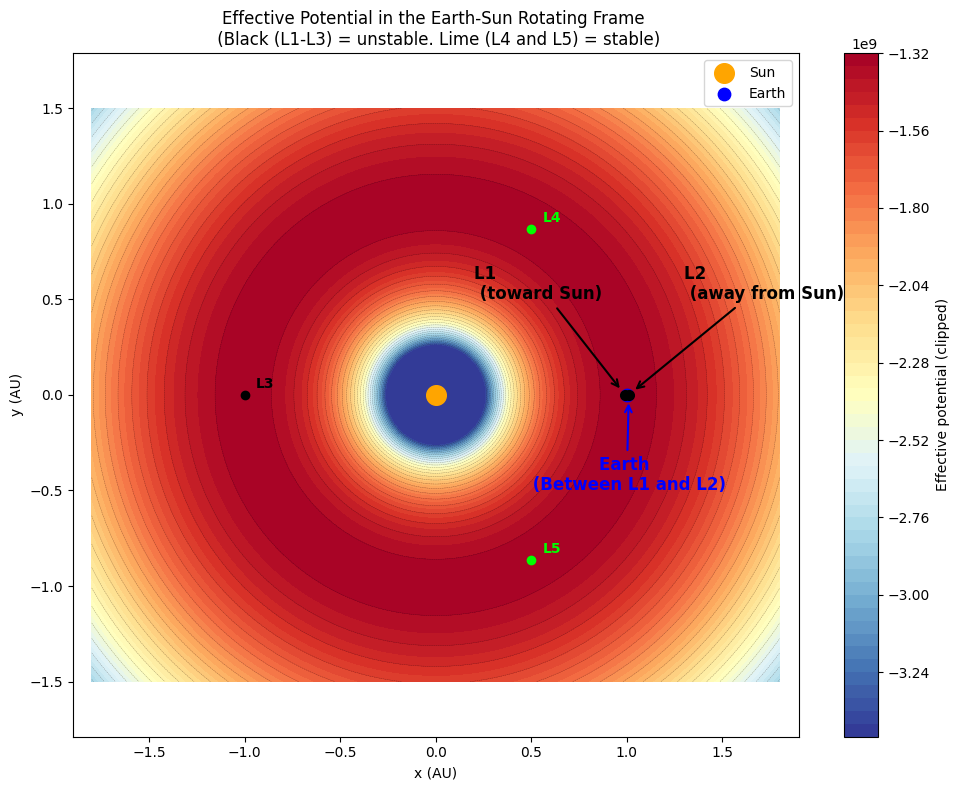

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#and i want to use fsolve
from scipy.optimize import fsolve

#constants
G = 6.6743e-11
M_sun = 1.989e30
M_earth = 5.972e24
AU = 1.496e11
M_total = M_sun + M_earth

#distance from sun to earth
d = 1 * AU
#place both on x-axis
x_sun   = -M_earth / M_total * d
x_earth =  M_sun   / M_total * d

#angular velocity of frame
omega = np.sqrt(G * M_total / d**3)

#Effective potential of frame
def U_eff(x,y):
    r_sun   = np.sqrt((x - x_sun)**2   + y**2)
    r_earth = np.sqrt((x - x_earth)**2 + y**2)
    return -G * M_sun / r_sun - G * M_earth / r_earth - 0.5 * omega**2 * (x**2 + y**2)

#Map of potentials on grid
res = 800
x_grid = np.linspace(-1.8 * AU, 1.8 * AU, res)
y_grid = np.linspace(-1.5 * AU, 1.5 * AU, res)
X, Y = np.meshgrid(x_grid, y_grid)
Z = U_eff(X, Y)

#Lagrange points are where the gradient of U_eff is 0
def grad_U(coords):
    x, y = coords
    eps = 1e6  # 1 km step for numerical gradient
    dUdx = (U_eff(x + eps, y) - U_eff(x - eps, y)) / (2 * eps)
    dUdy = (U_eff(x, y + eps) - U_eff(x, y - eps)) / (2 * eps)
    return [dUdx, dUdy]

#inital guesses, so it has somewhere to search from
guesses = {
    "L1": [ .8 * AU,  0],
    "L2": [ 1.01 * AU,  0],
    "L3": [-1.0  * AU,  0],
    "L4": [ 0.5  * AU,  np.sqrt(3)/2 * AU],
    "L5": [ 0.5  * AU, -np.sqrt(3)/2 * AU],
}

lagrange_points = {}
for name, guess in guesses.items():
    sol = fsolve(grad_U, guess, full_output=True)
    lagrange_points[name] = sol[0]

Z_plot = np.clip(Z, np.percentile(Z, 2), np.percentile(Z, 97))

plt.figure(figsize=(10, 8))
plt.contourf(X / AU, Y / AU, Z_plot, levels=60, cmap="RdYlBu_r")
plt.colorbar(label="Effective potential (clipped)")

plt.contour(X / AU, Y / AU, Z_plot, levels=30, colors="k", linewidths=0.3, alpha=0.4)

# Mark the bodies
plt.scatter([x_sun / AU],   [0], color="orange", s=200, zorder=5, label="Sun")
plt.scatter([x_earth / AU], [0], color="blue",   s=80,  zorder=5, label="Earth")

# Mark Lagrange points
colors = { "L1": "black", "L2": "black", "L3": "black", "L4": "lime", "L5": "lime"}
for name, (lx, ly) in lagrange_points.items():
    plt.scatter(lx / AU, ly / AU, color=colors[name], s=100, zorder=6, marker=".", linewidths=2)
    if name in ("L1", "L2"): #got too crowded
        continue
    plt.annotate(name, (lx / AU, ly / AU), textcoords="offset points",
                 xytext=(8, 5), fontsize=10, color=colors[name], fontweight="bold")

#L1 and L2 are too close, add arrows
lx, ly = lagrange_points["L1"]
plt.scatter(lx / AU, ly / AU, color="black", s=120, marker=".",
            linewidths=2.5, zorder=6)
plt.annotate("L1 \n (toward Sun)",
             xy=(lx / AU, ly / AU),
             xytext=(0.2, 0.5),
             fontsize=12, color="black", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black",
                             lw=1.5, shrinkB=6))

lx, ly = lagrange_points["L2"]
plt.scatter(lx / AU, ly / AU, color="black", s=120, marker=".",
            linewidths=2.5, zorder=6)
plt.annotate("L2 \n (away from Sun)",
             xy=(lx / AU, ly / AU),
             xytext=(1.3, 0.5),
             fontsize=12, color="black", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black",
                             lw=1.5, shrinkB=6))

#now, Earth looks covered
plt.annotate("Earth \n (Between L1 and L2)",
             xy=(lx / AU, ly / AU),
             xytext=(1, -0.5),
             fontsize=12, color="blue", fontweight="bold",
             ha="center",
             arrowprops=dict(arrowstyle="->", color="blue",
                             lw=1.5, shrinkB=6))

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Effective Potential in the Earth-Sun Rotating Frame \n (Black (L1-L3) = unstable. Lime (L4 and L5) = stable)")
plt.legend()
plt.axis("equal")
plt.tight_layout()
plt.show()

This plot shows the effective potential as a heatmap.


It is subject to 3 forces: gravity from the Sun, gravity from the Earth, and the centrifugal force from the rotation, shown by the equation: $$U_{\text{eff}}(x, y) = -\frac{GM_\odot}{r_\odot} - \frac{GM_\oplus}{r_\oplus} - \tfrac{1}{2}\omega^2(x^2 + y^2)$$

I mapped the effective potential on a grid and used fsolve, to find where the net force on the test mass was 0. The were the Lagrange points (L1, L2, L3,L4, L5).

L1, L2 and L3 are all along the same line as Earth. L3 is at ~-1 AU, L1 is at ~0.99 AU, Earth at 1.00 AU and L2 at ~1.01 AU. L1, L2 and L3 are unstable, saddle points. Unstable means any nudge or deviation grows over time. Thus, without using fuel, satelites at these points would disappear.

 L4 and L5 are stable points, if the mass ratio of the two large bodies (Sun and Earth) is greater than approximately 24.96.